Load Dataset

In [14]:
import sys
import os


sys.path.append(os.path.abspath("../src"))

In [32]:
from src.data_loader import load_data
from src.data_cleaning import clean_data
from src.eda_utils import plot_boxplot, plot_loss_ratio, plot_histogram;

df = load_data(
    "../data/MachineLearningRating_v3.txt"
)

df = clean_data(df)

df.head()

,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,...,CoverType,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims,LossRatio,Margin
0,145249,12827,2015-03-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0,0.0,21.929825
1,145249,12827,2015-05-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0,0.0,21.929825
2,145249,12827,2015-07-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0,0.0,0.000000
3,145255,12827,2015-05-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,512.848070,0.0,0.0,512.848070
4,145255,12827,2015-07-01,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0,0.0,0.000000


Dataset Overview

In [18]:
df.shape
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1000098 entries, 0 to 1000097
Data columns (total 54 columns):
 #   Column                    Non-Null Count    Dtype         
---  ------                    --------------    -----         
 0   UnderwrittenCoverID       1000098 non-null  int64         
 1   PolicyID                  1000098 non-null  int64         
 2   TransactionMonth          1000098 non-null  datetime64[us]
 3   IsVATRegistered           1000098 non-null  bool          
 4   Citizenship               1000098 non-null  str           
 5   LegalType                 1000098 non-null  str           
 6   Title                     1000098 non-null  str           
 7   Language                  1000098 non-null  str           
 8   Bank                      1000098 non-null  str           
 9   AccountType               1000098 non-null  str           
 10  MaritalStatus             1000098 non-null  str           
 11  Gender                    1000098 non-null  str           
 1

,UnderwrittenCoverID,PolicyID,TransactionMonth,PostalCode,mmcode,RegistrationYear,Cylinders,cubiccapacity,kilowatts,NumberOfDoors,CustomValueEstimate,NumberOfVehiclesInFleet,SumInsured,CalculatedPremiumPerTerm,TotalPremium,TotalClaims,LossRatio,Margin
count,1.000098e+06,1.000098e+06,1000098,1.000098e+06,1.000098e+06,1.000098e+06,1.000098e+06,1.000098e+06,1.000098e+06,1.000098e+06,1.000098e+06,0.0,1.000098e+06,1.000098e+06,1.000098e+06,1.000098e+06,1.000098e+06,1.000098e+06
mean,1.048175e+05,7.956682e+03,2015-02-28 10:49:29.147424,3.020601e+03,5.488056e+07,2.010225e+03,4.046616e+00,2.466869e+03,9.721553e+01,4.019239e+00,2.212193e+05,NaN,6.041727e+05,1.178757e+02,6.190550e+01,6.486119e+01,2.794202e+06,-2.955694e+00
min,1.000000e+00,1.400000e+01,2013-10-01 00:00:00,1.000000e+00,4.041200e+06,1.987000e+03,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e+04,NaN,1.000000e-02,0.000000e+00,-7.825768e+02,-1.200241e+04,-6.354800e+08,-3.928486e+05
25%,5.514300e+04,4.500000e+03,2015-01-01 00:00:00,8.270000e+02,6.005692e+07,2.008000e+03,4.000000e+00,2.237000e+03,7.500000e+01,4.000000e+00,2.200000e+05,NaN,5.000000e+03,3.224800e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,9.408300e+04,7.071000e+03,2015-04-01 00:00:00,2.000000e+03,6.005842e+07,2.011000e+03,4.000000e+00,2.694000e+03,1.110000e+02,4.000000e+00,2.200000e+05,NaN,7.500000e+03,8.436900e+00,2.178333e+00,0.000000e+00,0.000000e+00,2.157687e+00
75%,1.391900e+05,1.107700e+04,2015-06-01 00:00:00,4.180000e+03,6.005842e+07,2.013000e+03,4.000000e+00,2.694000e+03,1.110000e+02,4.000000e+00,2.200000e+05,NaN,2.500000e+05,9.000000e+01,2.192982e+01,0.000000e+00,0.000000e+00,2.192982e+01
max,3.011750e+05,2.324600e+04,2015-08-01 00:00:00,9.870000e+03,6.506535e+07,2.015000e+03,1.000000e+01,1.288000e+04,3.090000e+02,6.000000e+00,2.655000e+07,NaN,1.263620e+07,7.442217e+04,6.528260e+04,3.930921e+05,1.525895e+11,6.528260e+04
std,6.329371e+04,5.290039e+03,NaN,2.649854e+03,1.360059e+07,3.261391e+00,2.939410e-01,4.427106e+02,1.939061e+01,4.681854e-01,2.650521e+05,NaN,1.508332e+06,3.997017e+02,2.302845e+02,2.384075e+03,3.947653e+08,2.367137e+03


Missing Values

In [20]:
df.isnull().sum().sort_values(
    ascending=False
)


NumberOfVehiclesInFleet     1000098
UnderwrittenCoverID               0
TransactionMonth                  0
IsVATRegistered                   0
Citizenship                       0
PolicyID                          0
Title                             0
Language                          0
Bank                              0
AccountType                       0
MaritalStatus                     0
Gender                            0
Country                           0
Province                          0
PostalCode                        0
MainCrestaZone                    0
SubCrestaZone                     0
ItemType                          0
mmcode                            0
VehicleType                       0
RegistrationYear                  0
LegalType                         0
make                              0
Model                             0
cubiccapacity                     0
Cylinders                         0
bodytype                          0
NumberOfDoors               

Univariate Analysis

Total Premium Distribution

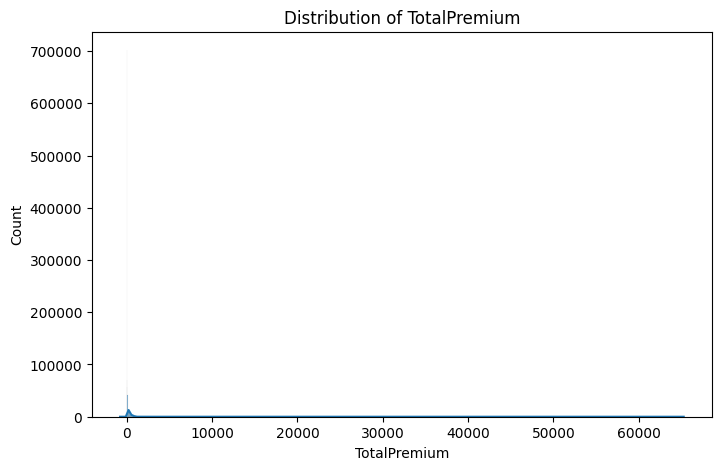

In [33]:
plot_histogram(df, "TotalPremium")

Total Claims Distribution

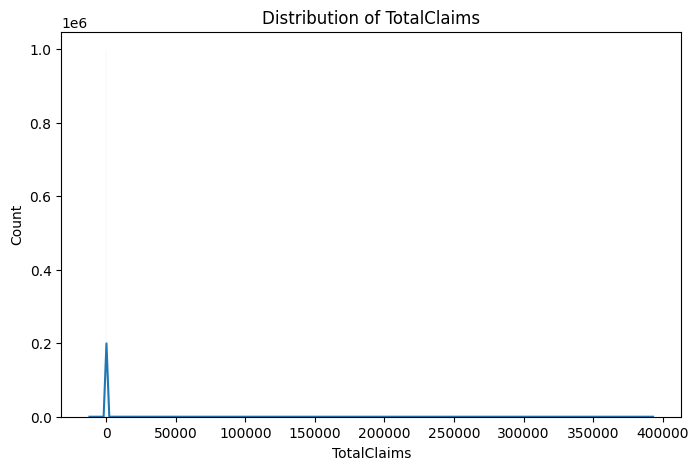

In [34]:
plot_histogram(df, "TotalClaims")

Outlier Detection


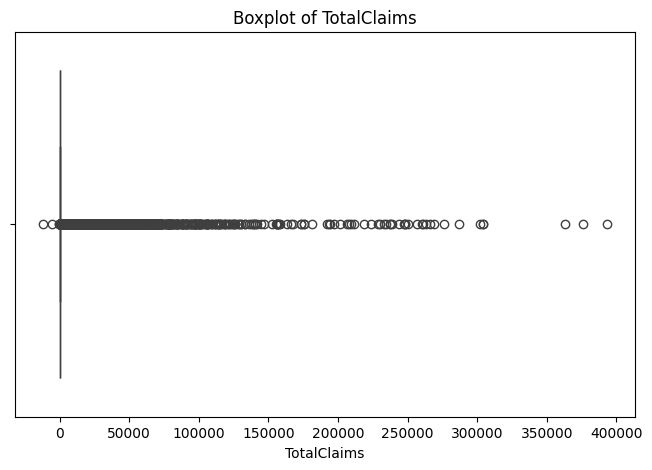

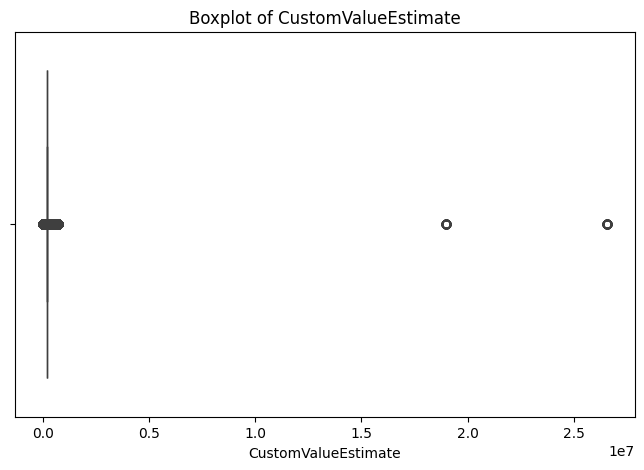

In [35]:
plot_boxplot(df, "TotalClaims")
plot_boxplot(df, "CustomValueEstimate")

Geographic Risk Analysis

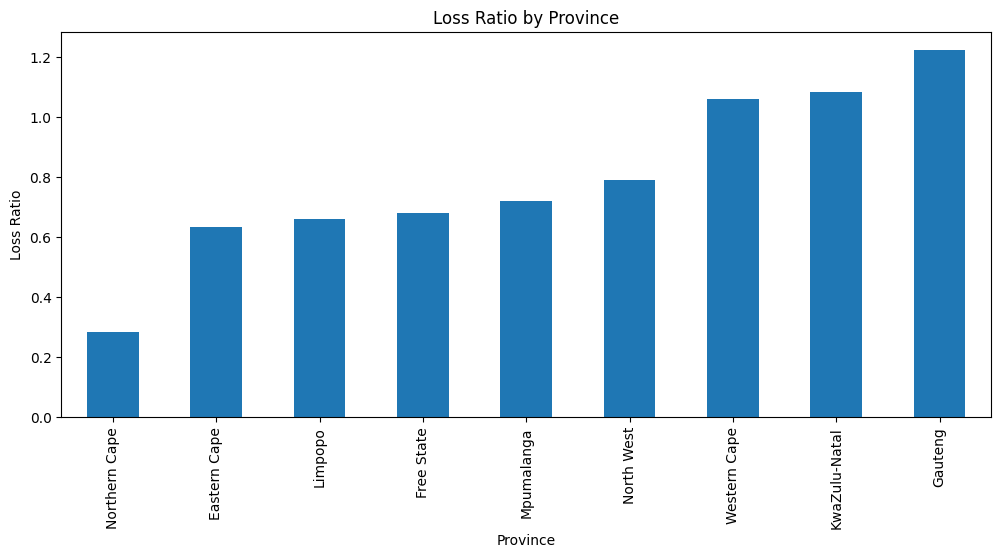

In [36]:
plot_loss_ratio(df, "Province")

Gender Risk Analysis

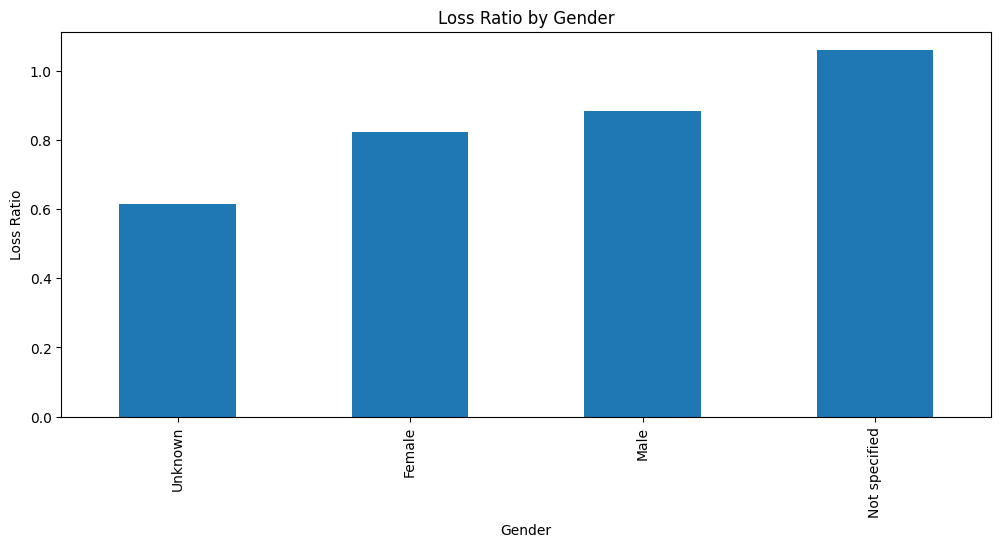

In [37]:
plot_loss_ratio(df, "Gender")

Vehicle Type Risk Analysis

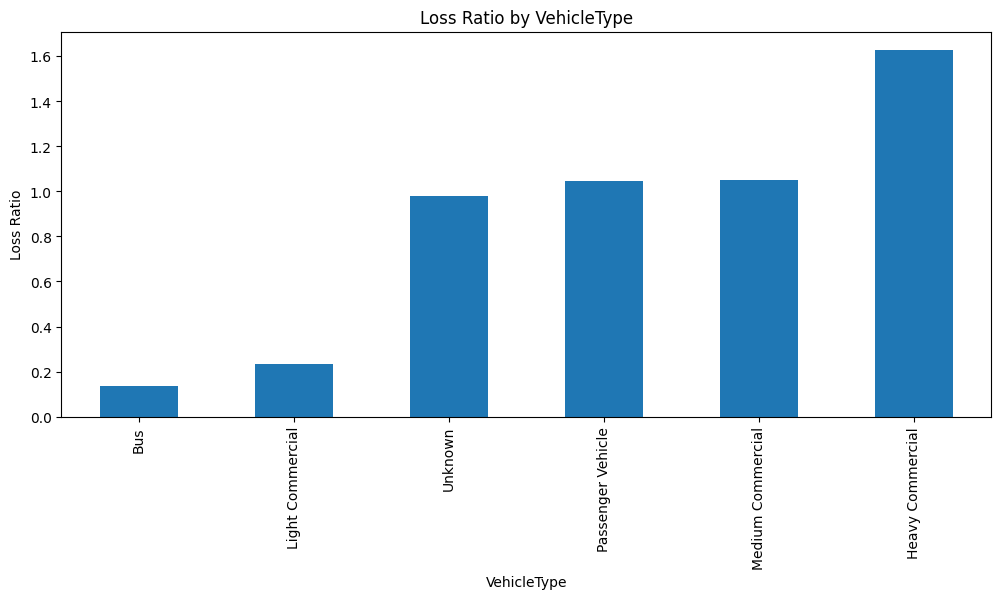

In [38]:
plot_loss_ratio(df, "VehicleType")

Monthly Claim Trend

<Axes: xlabel='TransactionMonth'>

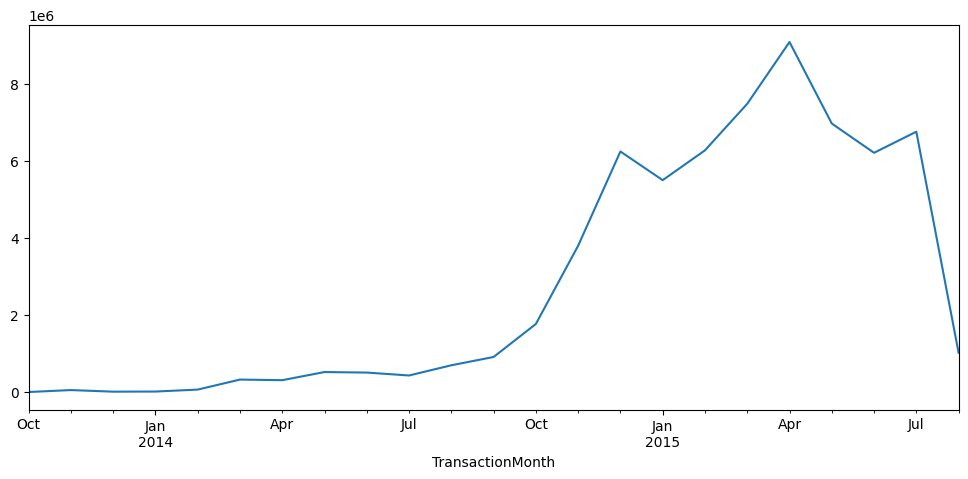

In [39]:
monthly_claims = (
    df.groupby("TransactionMonth")[
        "TotalClaims"
    ].sum()
)

monthly_claims.plot(
    figsize=(12, 5)
)

Correlation Matrix

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt
vehicle_claims = (
    df.groupby("Make")[
        "TotalClaims"
    ]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

vehicle_claims.plot(
    kind="bar",
    figsize=(12, 5)
)

corr = df[
    [
        "TotalPremium",
        "TotalClaims",
        "CustomValueEstimate",
        "Kilowatts",
        "Cubiccapacity"
    ]
].corr()

plt.figure(figsize=(10, 6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

KeyError: 'Make'

Insight

Province Risk
Gauteng exhibits a higher loss ratio than other provinces, suggesting elevated underwriting risk in this region.

Vehicle Risk
Mercedes-Benz vehicles show relatively high average claims, likely due to higher repair costs and insured values.

Claims Trend
Claims severity increased during mid-2015, indicating possible seasonal or operational risk changes.

